# Comparing the SAM 2.1 Checkpoints: Tiny vs Small vs Base+ vs Large

This notebook benchmarks the four SAM 2.1 Hiera checkpoints found in `../checkpoints/`:

| Name | Checkpoint file | Config |
|---|---|---|
| Tiny | `sam2.1_hiera_tiny.pt` | `configs/sam2.1/sam2.1_hiera_t.yaml` |
| Small | `sam2.1_hiera_small.pt` | `configs/sam2.1/sam2.1_hiera_s.yaml` |
| Base+ | `sam2.1_hiera_base_plus.pt` | `configs/sam2.1/sam2.1_hiera_b+.yaml` |
| Large | `sam2.1_hiera_large.pt` | `configs/sam2.1/sam2.1_hiera_l.yaml` |

For each model we measure:

1. **Checkpoint size on disk** and **parameter count** (total + per-component breakdown)
2. **Load time**
3. **Inference latency** (image encoding vs. mask decoding) and **peak GPU memory**
4. **Segmentation quality/agreement** — the same point prompt on the same image across all four models, compared against the Large model's mask via IoU
5. **Automatic mask generation** — number of masks, coverage, and time on the same image

Run this notebook from the `notebooks/` directory (same convention as the other SAM 2 example notebooks), with the `sam2` package installed in the active environment.

Each analysis section below loads one model at a time and frees it before moving to the next, so this stays runnable on modest GPUs — at the cost of reloading checkpoints a few times over the course of the notebook.

## Setup

In [1]:
import os
# if using Apple MPS, fall back to CPU for unsupported ops
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

import gc
import time

import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image

from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor
from sam2.automatic_mask_generator import SAM2AutomaticMaskGenerator

In [2]:
# select the device for computation
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"using device: {device}")

if device.type == "cuda":
    # use bfloat16 for the entire notebook
    torch.autocast("cuda", dtype=torch.bfloat16).__enter__()
    # turn on tfloat32 for Ampere GPUs (https://pytorch.org/docs/stable/notes/cuda.html#tensorfloat-32-tf32-on-ampere-devices)
    if torch.cuda.get_device_properties(0).major >= 8:
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True
elif device.type == "mps":
    print(
        "\nSupport for MPS devices is preliminary. SAM 2 is trained with CUDA and might "
        "give numerically different outputs and sometimes degraded performance on MPS. "
        "GPU memory benchmarking below is skipped on MPS/CPU."
    )

using device: cuda


## Plotting helpers

A fixed color per model, used consistently across every chart in this notebook (never reassigned based on sorting or filtering), plus a small `style_ax` helper to keep the charts clean and consistent.

In [3]:
# Fixed categorical palette, one hue per model, reused everywhere below.
MODEL_ORDER = ["tiny", "small", "base_plus", "large"]
MODEL_COLORS = {
    "tiny": "#2a78d6",       # blue
    "small": "#eb6834",      # orange
    "base_plus": "#1baf7a",  # aqua
    "large": "#eda100",      # yellow
}
INK = "#0b0b0b"
SECONDARY_INK = "#52514e"
MUTED = "#898781"
GRID = "#e1e0d9"

def style_ax(ax, ylabel=None, title=None):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.yaxis.grid(True, color=GRID, linewidth=1, zorder=0)
    ax.set_axisbelow(True)
    ax.tick_params(axis="both", colors=MUTED, length=0)
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_color(SECONDARY_INK)
    if ylabel:
        ax.set_ylabel(ylabel, color=SECONDARY_INK)
    if title:
        ax.set_title(title, color=INK, fontsize=13, loc="left")

def bar_labels(ax, bars, fmt="{:.0f}"):
    for b in bars:
        h = b.get_height()
        ax.annotate(
            fmt.format(h),
            xy=(b.get_x() + b.get_width() / 2, h),
            xytext=(0, 3),
            textcoords="offset points",
            ha="center",
            va="bottom",
            color=INK,
            fontsize=9,
        )

## Model registry

In [4]:
MODEL_SPECS = {
    "tiny":      {"config": "configs/sam2.1/sam2.1_hiera_t.yaml",  "ckpt": "../checkpoints/sam2.1_hiera_tiny.pt"},
    "small":     {"config": "configs/sam2.1/sam2.1_hiera_s.yaml",  "ckpt": "../checkpoints/sam2.1_hiera_small.pt"},
    "base_plus": {"config": "configs/sam2.1/sam2.1_hiera_b+.yaml", "ckpt": "../checkpoints/sam2.1_hiera_base_plus.pt"},
    "large":     {"config": "configs/sam2.1/sam2.1_hiera_l.yaml",  "ckpt": "../checkpoints/sam2.1_hiera_large.pt"},
}

for name in MODEL_ORDER:
    spec = MODEL_SPECS[name]
    assert os.path.isfile(spec["ckpt"]), f"missing checkpoint: {spec['ckpt']}"

# `results[name]` accumulates every metric measured in this notebook.
results = {name: {} for name in MODEL_ORDER}


def build_model(name, apply_postprocessing=True):
    spec = MODEL_SPECS[name]
    return build_sam2(spec["config"], spec["ckpt"], device=device, apply_postprocessing=apply_postprocessing)


def release_cuda_cache():
    # `del` on the model/predictor variables must happen in the SAME scope that
    # holds them (a function's locals, or this notebook's globals) *before*
    # calling this -- deleting a reference inside a helper only drops that
    # helper's own copy, not the caller's, so it would not actually free memory.
    gc.collect()
    if device.type == "cuda":
        # We enter `autocast` once above and never exit it, so its bf16
        # weight-cast cache is never cleared automatically -- without this it
        # keeps a casted copy of every model's weights alive for the rest of
        # the process, which quietly exhausts GPU memory after a few models.
        torch.clear_autocast_cache()
        torch.cuda.synchronize()
        torch.cuda.empty_cache()

## 1. Checkpoint size on disk

In [5]:
for name in MODEL_ORDER:
    size_mb = os.path.getsize(MODEL_SPECS[name]["ckpt"]) / (1024 ** 2)
    results[name]["file_size_mb"] = size_mb
    print(f"{name:>10s}: {size_mb:8.1f} MB")

      tiny:    148.8 MB
     small:    175.9 MB
 base_plus:    308.6 MB
     large:    856.5 MB


## 2. Parameter counts and load time

Each model is built once here (config + checkpoint -> `nn.Module` on `device`), timed, broken down by top-level component, then freed before the next one loads.

In [6]:
COMPONENTS = ["image_encoder", "memory_attention", "memory_encoder", "sam_prompt_encoder", "sam_mask_decoder"]

def count_parameters(module):
    return sum(p.numel() for p in module.parameters())

def component_breakdown(sam2_model):
    breakdown = {}
    for comp in COMPONENTS:
        module = getattr(sam2_model, comp, None)
        breakdown[comp] = count_parameters(module) if module is not None else 0
    breakdown["other"] = count_parameters(sam2_model) - sum(breakdown.values())
    return breakdown

In [7]:
for name in MODEL_ORDER:
    t0 = time.perf_counter()
    sam2_model = build_model(name)
    if device.type == "cuda":
        torch.cuda.synchronize()
    load_time_s = time.perf_counter() - t0

    results[name]["load_time_s"] = load_time_s
    results[name]["total_params"] = count_parameters(sam2_model)
    results[name]["param_breakdown"] = component_breakdown(sam2_model)

    print(f"{name:>10s}: load {load_time_s:5.2f}s   params {results[name]['total_params'] / 1e6:7.2f}M")

    del sam2_model
    release_cuda_cache()

      tiny: load  0.43s   params   38.96M
     small: load  0.26s   params   46.06M
 base_plus: load  0.39s   params   80.85M
     large: load  0.92s   params  224.45M


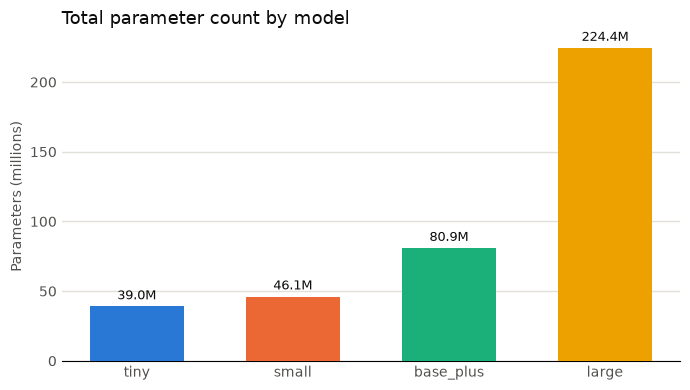

In [8]:
fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(MODEL_ORDER))
heights = [results[n]["total_params"] / 1e6 for n in MODEL_ORDER]
bars = ax.bar(x, heights, color=[MODEL_COLORS[n] for n in MODEL_ORDER], width=0.6, zorder=3)
ax.set_xticks(x)
ax.set_xticklabels(MODEL_ORDER)
style_ax(ax, ylabel="Parameters (millions)", title="Total parameter count by model")
bar_labels(ax, bars, fmt="{:.1f}M")
plt.tight_layout()
plt.show()

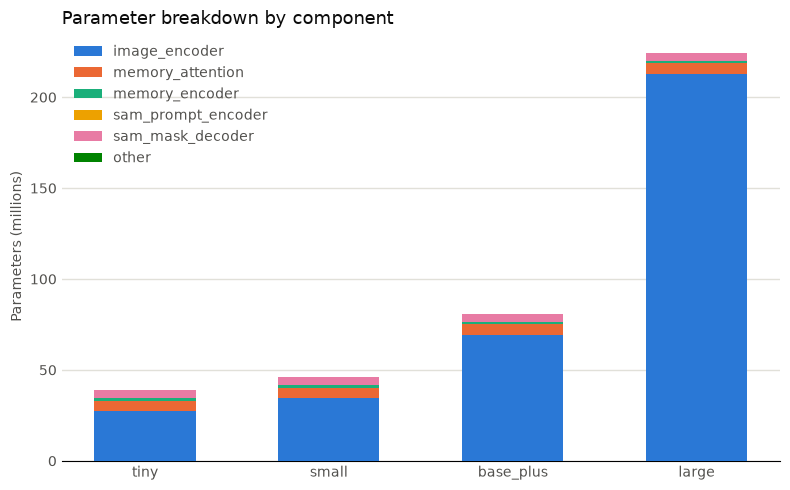

In [9]:
# Parameter breakdown by component, stacked per model. Components use the same
# fixed categorical order in every model's stack (never reordered by size).
component_order = COMPONENTS + ["other"]
component_colors = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300"]

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(MODEL_ORDER))
bottoms = np.zeros(len(MODEL_ORDER))
for comp, color in zip(component_order, component_colors):
    heights = np.array([results[n]["param_breakdown"][comp] / 1e6 for n in MODEL_ORDER])
    ax.bar(x, heights, bottom=bottoms, label=comp, color=color, width=0.55, zorder=3)
    bottoms += heights
ax.set_xticks(x)
ax.set_xticklabels(MODEL_ORDER)
style_ax(ax, ylabel="Parameters (millions)", title="Parameter breakdown by component")
ax.legend(frameon=False, loc="upper left", labelcolor=SECONDARY_INK)
plt.tight_layout()
plt.show()

## Sample image

Used for both the latency benchmark and the segmentation-quality comparison below.

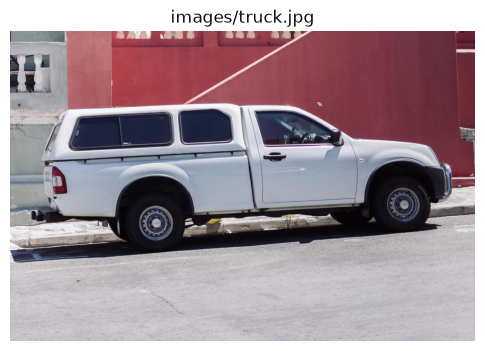

In [10]:
image = Image.open("images/truck.jpg")
image = np.array(image.convert("RGB"))

plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.axis("off")
plt.title("images/truck.jpg", color=INK)
plt.show()

## 3. Inference latency and peak GPU memory

For each model we time `set_image` (the image encoder forward pass) and `predict` (prompt encoder + mask decoder) separately, with a few warm-up iterations excluded from the timing, then read back peak allocated GPU memory for that model's forward passes.

In [11]:
N_WARMUP = 3
N_ITERS = 10
POINT = np.array([[500, 375]])
POINT_LABEL = np.array([1])

def benchmark_predictor(name, image, n_warmup=N_WARMUP, n_iters=N_ITERS):
    if device.type == "cuda":
        torch.cuda.reset_peak_memory_stats()

    sam2_model = build_model(name)
    predictor = SAM2ImagePredictor(sam2_model)

    def timed(fn):
        if device.type == "cuda":
            torch.cuda.synchronize()
        t0 = time.perf_counter()
        out = fn()
        if device.type == "cuda":
            torch.cuda.synchronize()
        return out, time.perf_counter() - t0

    for _ in range(n_warmup):
        _, _ = timed(lambda: predictor.set_image(image))
        _, _ = timed(lambda: predictor.predict(point_coords=POINT, point_labels=POINT_LABEL, multimask_output=True))

    encode_times, decode_times = [], []
    for _ in range(n_iters):
        _, dt = timed(lambda: predictor.set_image(image))
        encode_times.append(dt)
        _, dt = timed(lambda: predictor.predict(point_coords=POINT, point_labels=POINT_LABEL, multimask_output=True))
        decode_times.append(dt)

    peak_mem_mb = torch.cuda.max_memory_allocated() / (1024 ** 2) if device.type == "cuda" else None

    del predictor, sam2_model
    release_cuda_cache()

    return {
        "encode_ms_mean": float(np.mean(encode_times) * 1000),
        "encode_ms_std": float(np.std(encode_times) * 1000),
        "decode_ms_mean": float(np.mean(decode_times) * 1000),
        "decode_ms_std": float(np.std(decode_times) * 1000),
        "peak_mem_mb": peak_mem_mb,
    }

In [12]:
for name in MODEL_ORDER:
    bench = benchmark_predictor(name, image)
    results[name]["latency"] = bench
    mem_str = f"{bench['peak_mem_mb']:7.0f} MB" if bench["peak_mem_mb"] is not None else "     n/a"
    print(
        f"{name:>10s}: encode {bench['encode_ms_mean']:7.1f}ms  "
        f"decode {bench['decode_ms_mean']:6.1f}ms  peak mem {mem_str}"
    )

      tiny: encode    40.7ms  decode    6.7ms  peak mem     564 MB
     small: encode    44.6ms  decode    5.1ms  peak mem     607 MB
 base_plus: encode    77.5ms  decode    5.3ms  peak mem     840 MB
     large: encode   167.4ms  decode    5.3ms  peak mem    1711 MB


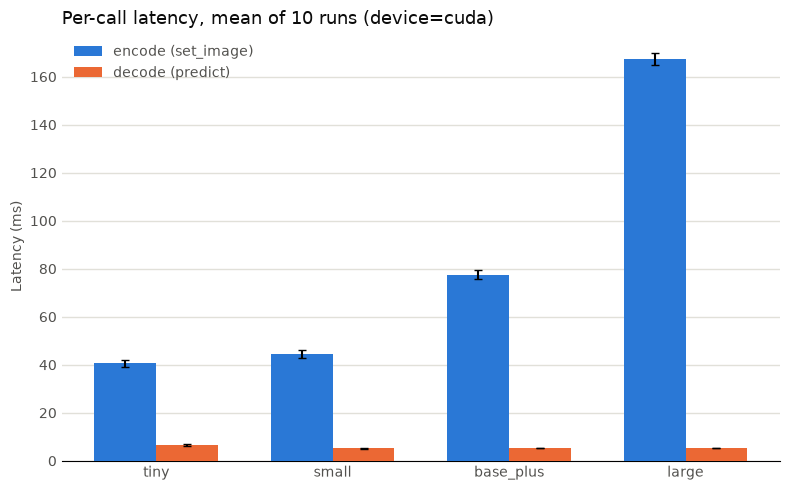

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(MODEL_ORDER))
width = 0.35
encode = [results[n]["latency"]["encode_ms_mean"] for n in MODEL_ORDER]
decode = [results[n]["latency"]["decode_ms_mean"] for n in MODEL_ORDER]
encode_err = [results[n]["latency"]["encode_ms_std"] for n in MODEL_ORDER]
decode_err = [results[n]["latency"]["decode_ms_std"] for n in MODEL_ORDER]

b1 = ax.bar(x - width / 2, encode, width, yerr=encode_err, capsize=3, label="encode (set_image)", color="#2a78d6", zorder=3)
b2 = ax.bar(x + width / 2, decode, width, yerr=decode_err, capsize=3, label="decode (predict)", color="#eb6834", zorder=3)
ax.set_xticks(x)
ax.set_xticklabels(MODEL_ORDER)
style_ax(ax, ylabel="Latency (ms)", title=f"Per-call latency, mean of {N_ITERS} runs (device={device.type})")
ax.legend(frameon=False, loc="upper left", labelcolor=SECONDARY_INK)
plt.tight_layout()
plt.show()

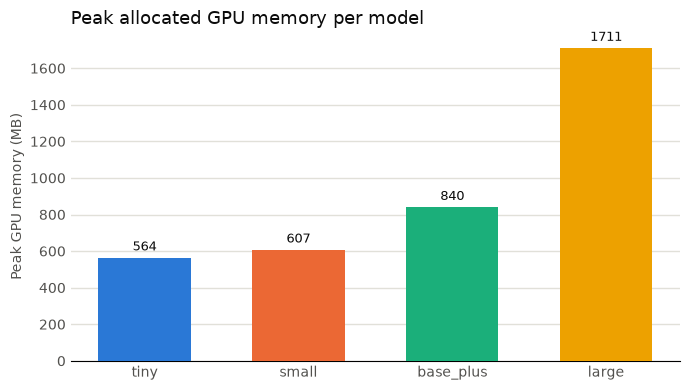

In [14]:
if device.type == "cuda":
    fig, ax = plt.subplots(figsize=(7, 4))
    heights = [results[n]["latency"]["peak_mem_mb"] for n in MODEL_ORDER]
    bars = ax.bar(x, heights, color=[MODEL_COLORS[n] for n in MODEL_ORDER], width=0.6, zorder=3)
    ax.set_xticks(x)
    ax.set_xticklabels(MODEL_ORDER)
    style_ax(ax, ylabel="Peak GPU memory (MB)", title="Peak allocated GPU memory per model")
    bar_labels(ax, bars, fmt="{:.0f}")
    plt.tight_layout()
    plt.show()
else:
    print(f"Skipping GPU memory chart: running on {device.type}.")

## 4. Segmentation quality agreement across models

Same point prompt, same image, all four models — do the smaller/faster models agree with the Large model's mask? We take each model's own best mask (`multimask_output=True`, highest predicted IoU score) and compare it against Large's best mask with pixel-wise IoU.

In [15]:
def mask_iou(a, b):
    a, b = a.astype(bool), b.astype(bool)
    union = np.logical_or(a, b).sum()
    if union == 0:
        return 1.0
    return float(np.logical_and(a, b).sum()) / float(union)

def show_mask(mask, ax, color=(30 / 255, 144 / 255, 255 / 255, 0.6)):
    h, w = mask.shape[-2:]
    mask_image = mask.reshape(h, w, 1) * np.array(color).reshape(1, 1, -1)
    ax.imshow(mask_image)

In [16]:
best_masks = {}
for name in MODEL_ORDER:
    sam2_model = build_model(name)
    predictor = SAM2ImagePredictor(sam2_model)
    predictor.set_image(image)
    masks, scores, _ = predictor.predict(point_coords=POINT, point_labels=POINT_LABEL, multimask_output=True)
    best = int(np.argmax(scores))
    best_masks[name] = masks[best]
    results[name]["quality"] = {"score": float(scores[best])}

    del predictor, sam2_model
    release_cuda_cache()

reference = best_masks["large"]
for name in MODEL_ORDER:
    iou_vs_large = mask_iou(best_masks[name], reference)
    results[name]["quality"]["iou_vs_large"] = iou_vs_large
    print(f"{name:>10s}: score {results[name]['quality']['score']:.3f}   IoU vs large {iou_vs_large:.3f}")

      tiny: score 0.953   IoU vs large 0.969
     small: score 0.938   IoU vs large 0.975
 base_plus: score 0.871   IoU vs large 0.979
     large: score 0.773   IoU vs large 1.000


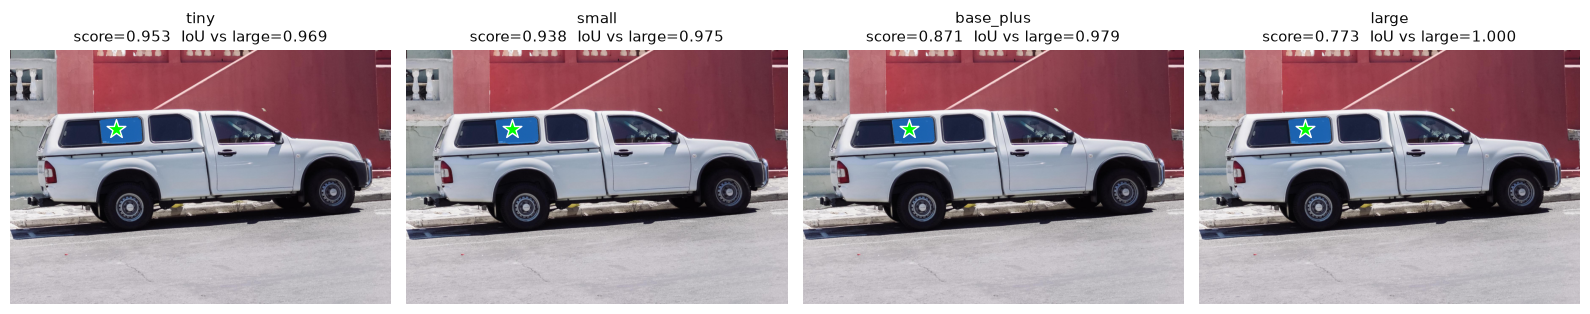

In [17]:
fig, axes = plt.subplots(1, len(MODEL_ORDER), figsize=(4 * len(MODEL_ORDER), 4))
for ax, name in zip(axes, MODEL_ORDER):
    ax.imshow(image)
    show_mask(best_masks[name], ax)
    ax.scatter(POINT[:, 0], POINT[:, 1], color="lime", marker="*", s=200, edgecolor="white", linewidth=1)
    q = results[name]["quality"]
    ax.set_title(f"{name}\nscore={q['score']:.3f}  IoU vs large={q['iou_vs_large']:.3f}", fontsize=11, color=INK)
    ax.axis("off")
plt.tight_layout()
plt.show()

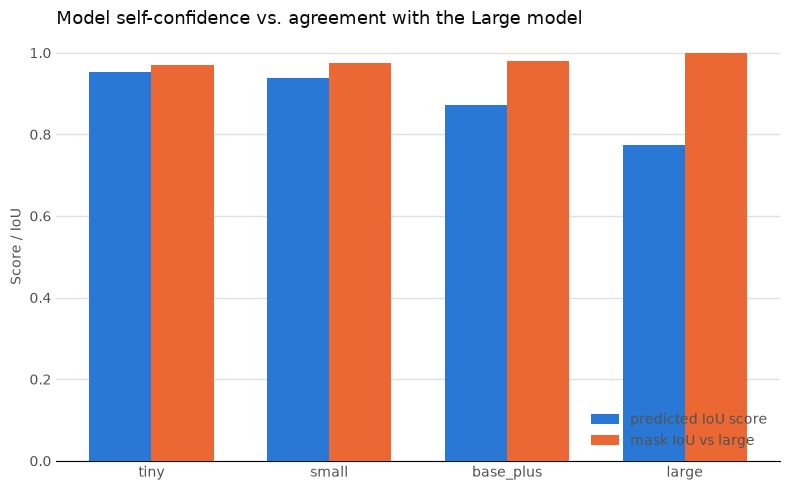

In [18]:
fig, ax = plt.subplots(figsize=(8, 5))
width = 0.35
scores = [results[n]["quality"]["score"] for n in MODEL_ORDER]
ious = [results[n]["quality"]["iou_vs_large"] for n in MODEL_ORDER]

b1 = ax.bar(x - width / 2, scores, width, label="predicted IoU score", color="#2a78d6", zorder=3)
b2 = ax.bar(x + width / 2, ious, width, label="mask IoU vs large", color="#eb6834", zorder=3)
ax.set_xticks(x)
ax.set_xticklabels(MODEL_ORDER)
ax.set_ylim(0, 1.05)
style_ax(ax, ylabel="Score / IoU", title="Model self-confidence vs. agreement with the Large model")
ax.legend(frameon=False, loc="lower right", labelcolor=SECONDARY_INK)
plt.tight_layout()
plt.show()

## 5. Automatic mask generation

`SAM2AutomaticMaskGenerator` densely prompts the model over a grid of points. This exercises the whole pipeline much harder than a single point prompt, so it's a good place to compare how many objects each model finds and how long that takes end to end.

We use a smaller `points_per_side`/`points_per_batch` than the library defaults (which are tuned for Large on a big GPU) so this section also fits on modest GPUs; the comparison across models is still apples-to-apples since every model uses the same settings. Each model is wrapped in a `try/except` for `OutOfMemoryError` so one model running out of memory doesn't stop the rest of the notebook.

In [19]:
np.random.seed(3)

def show_anns(anns, ax, borders=True):
    if len(anns) == 0:
        return
    sorted_anns = sorted(anns, key=(lambda a: a["area"]), reverse=True)
    img = np.ones((sorted_anns[0]["segmentation"].shape[0], sorted_anns[0]["segmentation"].shape[1], 4))
    img[:, :, 3] = 0
    for ann in sorted_anns:
        m = ann["segmentation"]
        color_mask = np.concatenate([np.random.random(3), [0.5]])
        img[m] = color_mask
        if borders:
            import cv2
            contours, _ = cv2.findContours(m.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
            contours = [cv2.approxPolyDP(c, epsilon=0.01, closed=True) for c in contours]
            cv2.drawContours(img, contours, -1, (0, 0, 1, 0.4), thickness=1)
    ax.imshow(img)

In [20]:
auto_image = Image.open("images/cars.jpg")
auto_image = np.array(auto_image.convert("RGB"))

auto_masks = {}
for name in MODEL_ORDER:
    sam2_model = build_model(name, apply_postprocessing=False)
    mask_generator = SAM2AutomaticMaskGenerator(
        sam2_model, points_per_side=24, points_per_batch=16
    )

    try:
        if device.type == "cuda":
            torch.cuda.synchronize()
        t0 = time.perf_counter()
        masks = mask_generator.generate(auto_image)
        if device.type == "cuda":
            torch.cuda.synchronize()
        gen_time_s = time.perf_counter() - t0
    except torch.cuda.OutOfMemoryError:
        print(f"{name:>10s}: ran out of GPU memory, skipping")
        results[name]["auto_mask"] = None
        auto_masks[name] = None
        del mask_generator, sam2_model
        release_cuda_cache()
        continue

    areas = np.array([m["area"] for m in masks]) if masks else np.array([0.0])
    results[name]["auto_mask"] = {
        "num_masks": len(masks),
        "gen_time_s": gen_time_s,
        "mean_area_px": float(areas.mean()),
        # Candidate masks overlap (a car, its door, and its window can each be
        # their own mask), so this routinely exceeds 1.0 -- it's not scene coverage.
        "total_area_ratio": float(areas.sum() / (auto_image.shape[0] * auto_image.shape[1])),
    }
    auto_masks[name] = masks

    print(
        f"{name:>10s}: {len(masks):3d} masks   {gen_time_s:6.2f}s   "
        f"total mask area {results[name]['auto_mask']['total_area_ratio']:5.2f}x image area"
    )

    del mask_generator, sam2_model
    release_cuda_cache()

      tiny:  19 masks     2.17s   total mask area  1.03x image area
     small:  30 masks     2.18s   total mask area  0.71x image area
 base_plus:  48 masks     2.29s   total mask area  1.27x image area
     large:  61 masks     2.35s   total mask area  1.70x image area


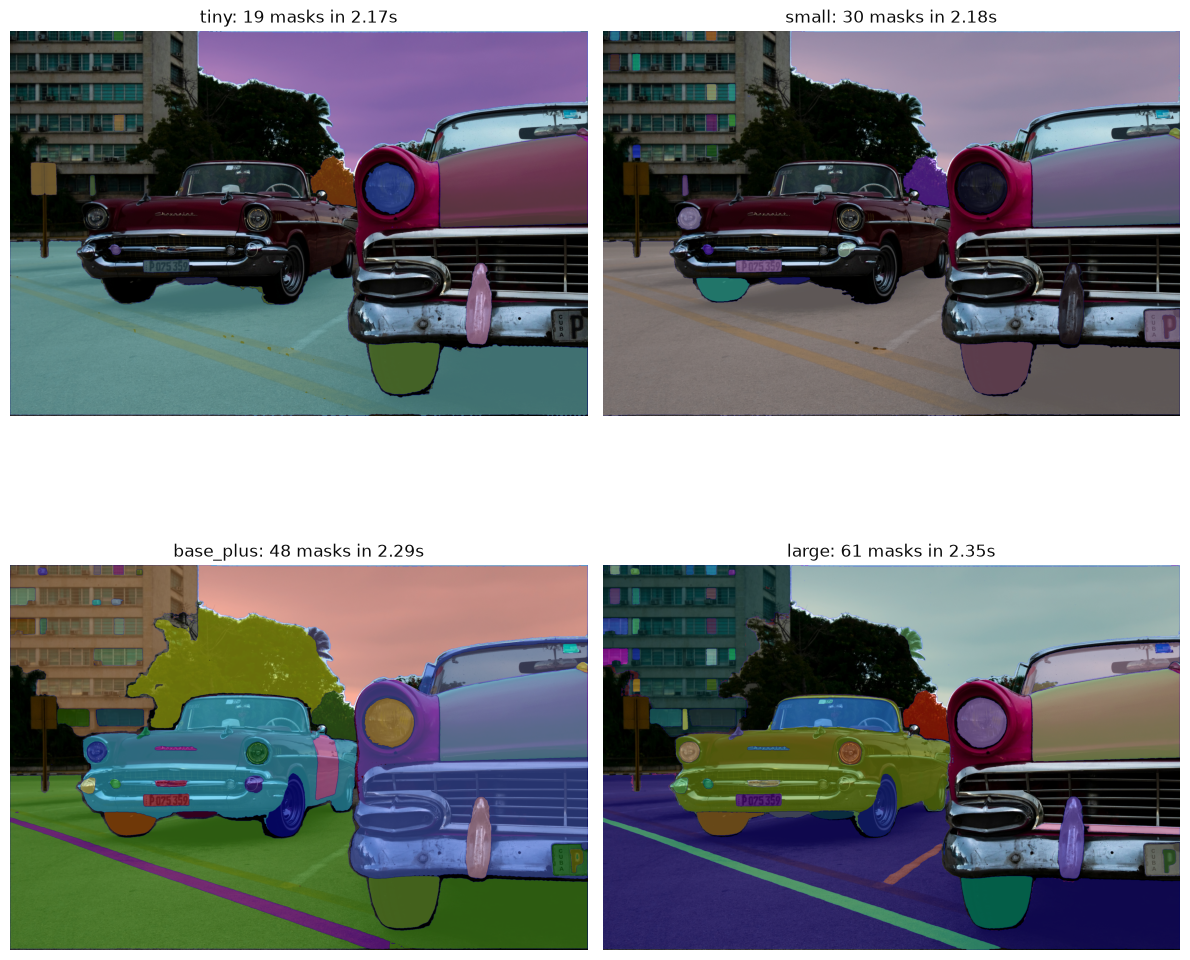

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(12, 12))
for ax, name in zip(axes.flat, MODEL_ORDER):
    ax.imshow(auto_image)
    am = results[name]["auto_mask"]
    if am is None:
        ax.set_title(f"{name}: skipped (out of GPU memory)", fontsize=12, color=INK)
    else:
        show_anns(auto_masks[name], ax)
        ax.set_title(f"{name}: {am['num_masks']} masks in {am['gen_time_s']:.2f}s", fontsize=12, color=INK)
    ax.axis("off")
plt.tight_layout()
plt.show()

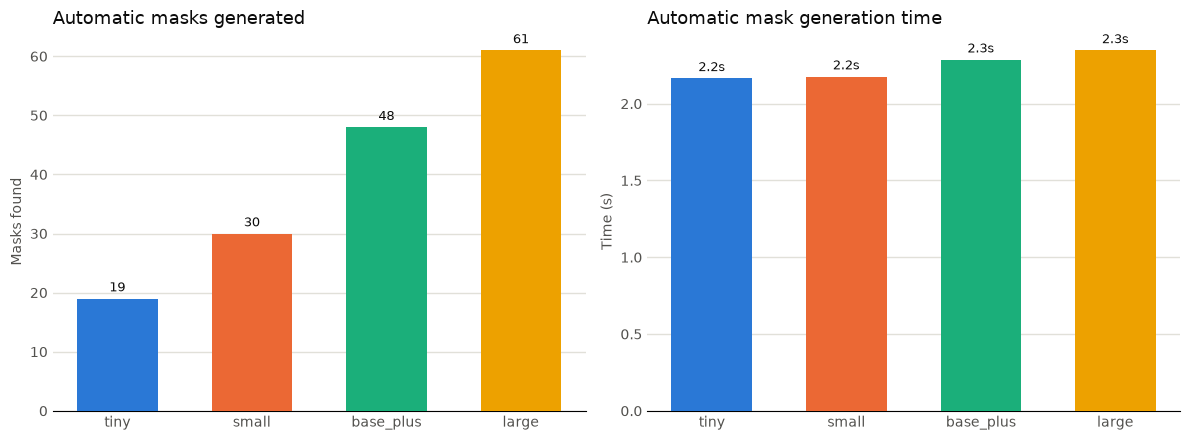

In [22]:
plotted = [n for n in MODEL_ORDER if results[n]["auto_mask"] is not None]
skipped = [n for n in MODEL_ORDER if results[n]["auto_mask"] is None]
if skipped:
    print(f"Excluded from these charts (ran out of GPU memory): {skipped}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
xp = np.arange(len(plotted))

num_masks = [results[n]["auto_mask"]["num_masks"] for n in plotted]
bars0 = axes[0].bar(xp, num_masks, color=[MODEL_COLORS[n] for n in plotted], width=0.6, zorder=3)
style_ax(axes[0], ylabel="Masks found", title="Automatic masks generated")
axes[0].set_xticks(xp)
axes[0].set_xticklabels(plotted)
bar_labels(axes[0], bars0, fmt="{:.0f}")

gen_times = [results[n]["auto_mask"]["gen_time_s"] for n in plotted]
bars1 = axes[1].bar(xp, gen_times, color=[MODEL_COLORS[n] for n in plotted], width=0.6, zorder=3)
style_ax(axes[1], ylabel="Time (s)", title="Automatic mask generation time")
axes[1].set_xticks(xp)
axes[1].set_xticklabels(plotted)
bar_labels(axes[1], bars1, fmt="{:.1f}s")

plt.tight_layout()
plt.show()

## 6. Summary

In [23]:
header = f"{'model':>10s} {'size(MB)':>10s} {'params(M)':>10s} {'load(s)':>9s} {'enc(ms)':>9s} {'dec(ms)':>9s} {'mem(MB)':>9s} {'IoU@lg':>8s} {'#masks':>8s} {'auto(s)':>8s}"
print(header)
print("-" * len(header))
for name in MODEL_ORDER:
    r = results[name]
    mem = f"{r['latency']['peak_mem_mb']:.0f}" if r["latency"]["peak_mem_mb"] is not None else "n/a"
    if r["auto_mask"] is not None:
        num_masks_str = f"{r['auto_mask']['num_masks']:8d}"
        auto_time_str = f"{r['auto_mask']['gen_time_s']:8.2f}"
    else:
        num_masks_str = f"{'oom':>8s}"
        auto_time_str = f"{'oom':>8s}"
    print(
        f"{name:>10s} {r['file_size_mb']:10.1f} {r['total_params'] / 1e6:10.2f} {r['load_time_s']:9.2f} "
        f"{r['latency']['encode_ms_mean']:9.1f} {r['latency']['decode_ms_mean']:9.1f} {mem:>9s} "
        f"{r['quality']['iou_vs_large']:8.3f} {num_masks_str} {auto_time_str}"
    )

     model   size(MB)  params(M)   load(s)   enc(ms)   dec(ms)   mem(MB)   IoU@lg   #masks  auto(s)
---------------------------------------------------------------------------------------------------
      tiny      148.8      38.96      0.43      40.7       6.7       564    0.969       19     2.17
     small      175.9      46.06      0.26      44.6       5.1       607    0.975       30     2.18
 base_plus      308.6      80.85      0.39      77.5       5.3       840    0.979       48     2.29
     large      856.5     224.45      0.92     167.4       5.3      1711    1.000       61     2.35


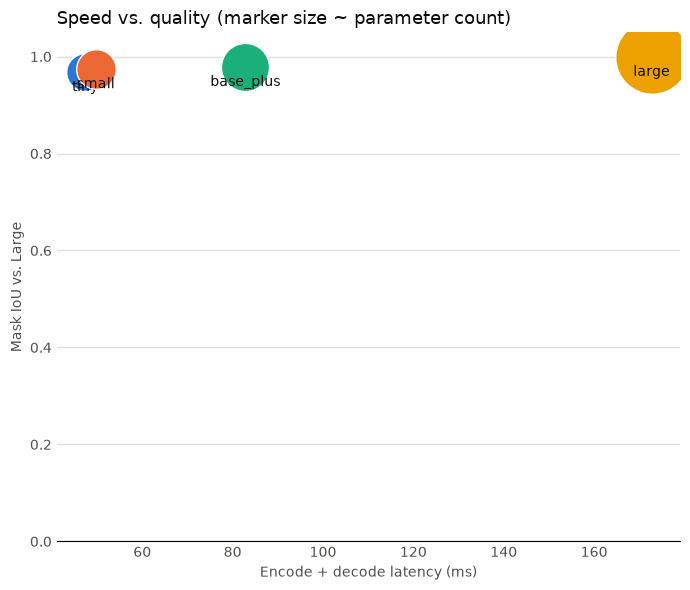

In [24]:
# Speed vs. quality tradeoff: total per-call latency (encode + decode) against
# agreement with the Large model's mask, point size ~ parameter count.
fig, ax = plt.subplots(figsize=(7, 6))
for name in MODEL_ORDER:
    r = results[name]
    total_latency = r["latency"]["encode_ms_mean"] + r["latency"]["decode_ms_mean"]
    size = 300 + 2500 * (r["total_params"] / results["large"]["total_params"])
    ax.scatter(total_latency, r["quality"]["iou_vs_large"], s=size, color=MODEL_COLORS[name], zorder=3, edgecolor="white", linewidth=1)
    ax.annotate(name, (total_latency, r["quality"]["iou_vs_large"]), textcoords="offset points", xytext=(0, -6), ha="center", va="top", fontsize=10, color=INK)

style_ax(ax, ylabel="Mask IoU vs. Large", title="Speed vs. quality (marker size ~ parameter count)")
ax.set_xlabel("Encode + decode latency (ms)", color=SECONDARY_INK)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

In [25]:
fastest = min(MODEL_ORDER, key=lambda n: results[n]["latency"]["encode_ms_mean"] + results[n]["latency"]["decode_ms_mean"])
smallest = min(MODEL_ORDER, key=lambda n: results[n]["total_params"])
closest_to_large = max((n for n in MODEL_ORDER if n != "large"), key=lambda n: results[n]["quality"]["iou_vs_large"])

print(f"Fastest end-to-end (encode+decode): {fastest}")
print(f"Smallest checkpoint / fewest parameters: {smallest}")
print(f"Best mask agreement with Large (excluding Large itself): {closest_to_large}")

ran_auto_mask = [n for n in MODEL_ORDER if results[n]["auto_mask"] is not None]
if ran_auto_mask:
    most_masks = max(ran_auto_mask, key=lambda n: results[n]["auto_mask"]["num_masks"])
    print(f"Most automatic masks found on images/cars.jpg: {most_masks}")
else:
    print("Automatic mask generation ran out of GPU memory for every model -- see section 5.")

Fastest end-to-end (encode+decode): tiny
Smallest checkpoint / fewest parameters: tiny
Best mask agreement with Large (excluding Large itself): base_plus
Most automatic masks found on images/cars.jpg: large


### Notes

- All timings are wall-clock on this machine/`device` and include Python-side overhead; treat relative ordering as more meaningful than absolute numbers.
- `iou_vs_large` measures agreement with the Large checkpoint's own best mask, not ground truth — it's a proxy for "how much segmentation quality do you give up by going smaller," not an absolute quality score.
- To extend this comparison to video, swap in `sam2.build_sam.build_sam2_video_predictor` and time `propagate_in_video` per model, following [video_predictor_example.ipynb](video_predictor_example.ipynb).